# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [4]:
from astropy import units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [10]:
speed_kmh = 60 * u.km / u.hour
speed_mps = speed_kmh.to(u.m / u.s)

print(f"{speed_mps:.3f}")

16.667 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [ ]:
# A Julian date is a count of days since JD 0, which is January 1st 4713 BCE (noon).

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [ ]:
# The main difference is that they treat leap years differently, where every 4 years is a leap year for the Julian Calendar, but the other has an exception for years divisible by 100 and not by 400 (e.g. 2100)

From the astropy module `time` import `Time` in the cell below.

In [12]:
from astropy import time

Find the Julian Date for **the current time**. 

In [14]:
from astropy.time import Time
now = Time.now()
print("Julian Date:", now.jd)

Julian Date: 2460756.535524362


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [4]:
from astropy.time import Time

t = Time("1969-07-02 20:17:00", scale='utc')

print("Julian Date:", t.jd)

Julian Date: 2440405.345138889


What historically happened at this date and time?

In [ ]:
# The Mars Climate Orbiter burnt up in the Martian atmosphere thanks to freedom units

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [1]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [4]:
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u

observation_time = Time.now()  # or specify like Time("2025-03-21T00:00:00")

obj_icrs = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

print("Celestial object in ICRS:")
print(obj_icrs)

Celestial object in ICRS:
<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>


Convert the object's coordinates from ICSRS to **Galactic**.

In [6]:
from astropy.coordinates import SkyCoord
from astropy import units as u

obj_icrs = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

obj_galactic = obj_icrs.galactic

print("Galactic Coordinates:")
print(f"Longitude (l): {obj_galactic.l}")
print(f"Latitude  (b): {obj_galactic.b}")

Galactic Coordinates:
Longitude (l): 138.7612378253739 deg
Latitude  (b): -82.60718782325382 deg


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [8]:
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
import astropy.units as u

obj_icrs = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

# location (Campbell Hall, UC Berkeley)
campbell_hall = EarthLocation(lat=37.8732*u.deg, lon=-122.2573*u.deg, height=88*u.m)

observation_time = Time.now()

altaz_frame = AltAz(obstime=observation_time, location=campbell_hall)
obj_altaz = obj_icrs.transform_to(altaz_frame)
print("AltAz Coordinates at Campbell Hall (UC Berkeley):")
print(f"Altitude: {obj_altaz.alt:.2f}")
print(f"Azimuth : {obj_altaz.az:.2f}")

AltAz Coordinates at Campbell Hall (UC Berkeley):
Altitude: 9.22 deg
Azimuth : 235.78 deg


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below & from astropy module `astropy.utils.data` import `download_file`.

In [19]:
from astropy.io import fits
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [12]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [21]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [23]:
with fits.open(image_file) as hdul:
    hdul.info() 
    data = hdul[0].data 
    header = hdul[0].header

Filename: C:\Users\golde\.astropy\cache\download\url\ff6e0b93871033c68022ca026a956d87\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [27]:
brightest_pixel = np.max(data)

print("Brightest pixel value:", brightest_pixel)

Brightest pixel value: 22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [31]:
darkest_pixel = np.min(data)

print("Dimmest pixel value:", darkest_pixel)

Dimmest pixel value: 3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [33]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [41]:
from astropy.table import Table

star_data = {
    'Name': ['Sirius', 'Canopus', 'Arcturus'],
    'Apparent Magnitude': [-1.46, -0.74, -0.05],
    'Spectral Type': ['A0mA1 Va, DA2', 'A9 II', 'K0 III']
}

star_table = Table(star_data)

Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [43]:
star_table.write('star_table.fits', format='fits', overwrite=True)

Read and print the table in the cell below from the `.fits` file you made.

In [45]:
read_table = Table.read('star_table.fits', format='fits')
print(read_table)

  Name   Apparent Magnitude Spectral Type
-------- ------------------ -------------
  Sirius              -1.46 A0mA1 Va, DA2
 Canopus              -0.74         A9 II
Arcturus              -0.05        K0 III


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [ ]:
# An H-R diagram is a scatter plot graphing the luminosity versus surface temperature of stars.

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [47]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [62]:
cluster_df = pd.read_csv(
    'cluster_data.csv',
    skiprows=44,
    sep=';',
    header=None,
    index_col=0,
    names=['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],
    skipfooter=1,
    engine='python'
)

Display the first few rows of the data.

In [64]:
cluster_df.head()

,Vmag,Plx,B-V,SpType
HIP,,,,
10,8.59,10.76,0.489,F6V
11,7.34,4.29,0.081,A2
12,8.43,4.06,1.484,K4III
13,8.80,3.49,1.128,K0III
14,7.25,5.11,1.200,K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [68]:
df_clean = cluster_df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

C:\Users\golde\AppData\Local\Temp\ipykernel_251196\2402926283.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = cluster_df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [70]:
cluster_df_clean = cluster_df.dropna()

Run the cell below. We are converting the datatypes in the columns to floats.

In [72]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  118208.000000  117946.000000  116928.000000
mean        8.373183       7.215046       0.706391
std         1.312023      11.286330       0.489828
min        -1.440000     -54.950000      -0.400000
25%         7.640000       2.510000       0.347000
50%         8.440000       4.610000       0.612000
75%         9.150000       8.410000       1.078000
max        14.080000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [74]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


C:\Users\golde\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\golde\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [ ]:
# The code is calculating the absolute magnitude of stars using the parallax and apparent magnitudes

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [76]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

ValueError: Cannot mask with non-boolean array containing NA / NaN values

What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [ ]:
# O is hottest, M is coldest

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [78]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

TypeError: 'float' object is not subscriptable

Import `matplotlib.pyplot` in the cell below.

In [80]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

C:\Users\golde\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\golde\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


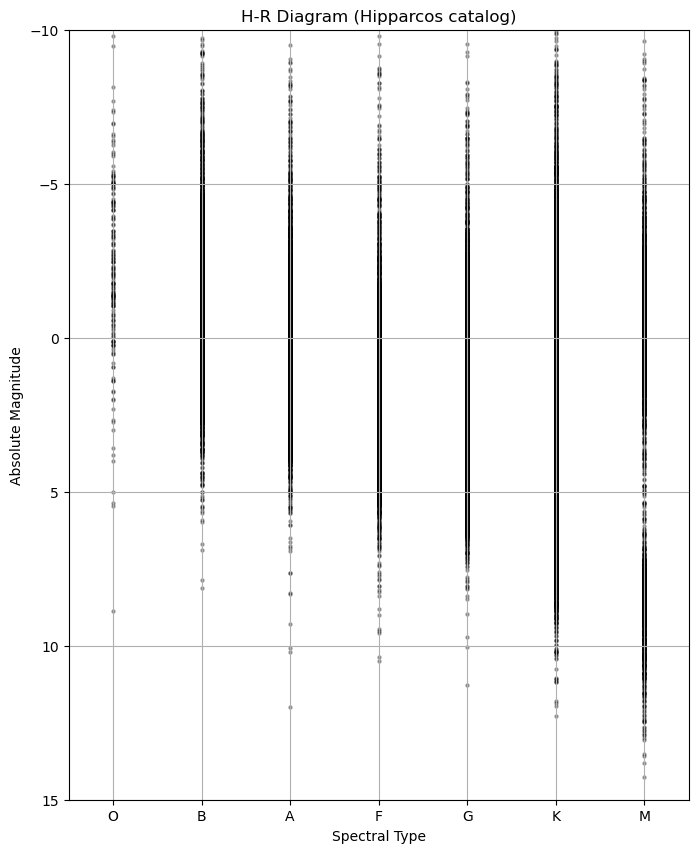

In [85]:
# Convert 'Plx' and 'Vmag' columns to numeric form
cluster_df_clean['Plx'] = pd.to_numeric(cluster_df_clean['Plx'], errors='coerce')
cluster_df_clean['Vmag'] = pd.to_numeric(cluster_df_clean['Vmag'], errors='coerce')

# Drop any rows that still contain NaNs in Plx or Vmag
cluster_df_clean = cluster_df_clean.dropna(subset=['Plx', 'Vmag'])

# Calculates absolute magnitude M_V
cluster_df_clean['M_V'] = cluster_df_clean['Vmag'] + 5 * np.log10(cluster_df_clean['Plx'] / 100)

spectral_mapping = {'O': 0, 'B': 10, 'A': 20, 'F': 30, 'G': 40, 'K': 50, 'M': 60}

def spectral_type_to_numeric(sptype):
    if isinstance(sptype, str) and sptype[0] in spectral_mapping:
        return spectral_mapping[sptype[0]] + 5
    return None

cluster_df_clean['SpType2_numeric'] = cluster_df_clean['SpType'].apply(spectral_type_to_numeric)

# Drop rows with NaNs in necessary columns
df_clean_plot = cluster_df_clean.dropna(subset=['SpType2_numeric', 'M_V'])

# Plotting the H-R Diagram
plt.figure(figsize=(8, 10))
plt.scatter(df_clean_plot['SpType2_numeric'], df_clean_plot['M_V'], s=5, alpha=0.3, c='k')

plt.xlim(0, 70)
plt.ylim(15, -10)
plt.xticks(range(5, 75, 10))
plt.gca().set_xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])

plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.grid(True)
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

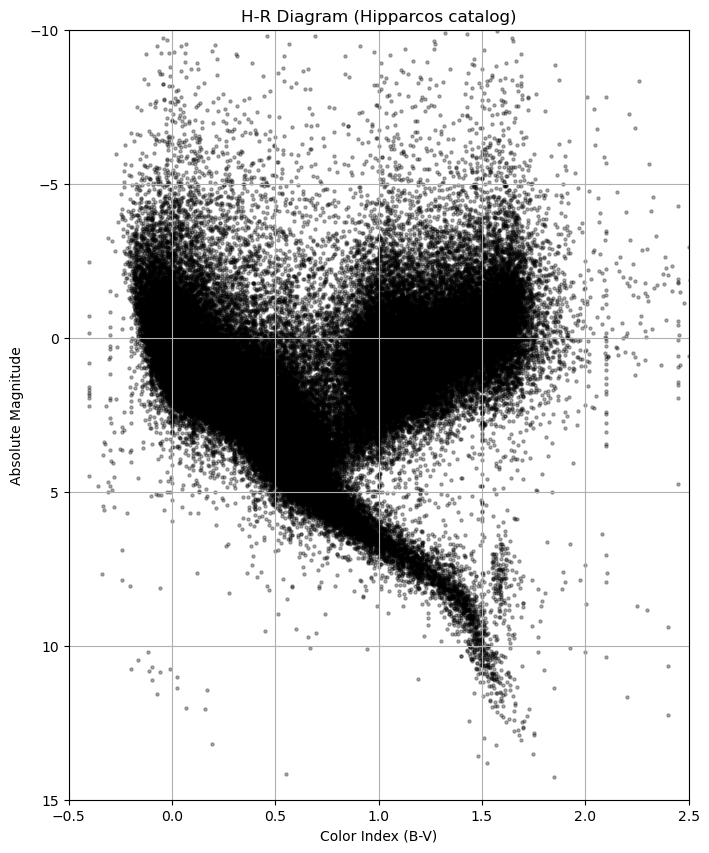

In [89]:
cluster_df_clean['B-V'] = pd.to_numeric(cluster_df_clean['B-V'], errors='coerce')

# This line drops any rows with missing B-V or M_V values
df_clean_color_plot = cluster_df_clean.dropna(subset=['B-V', 'M_V'])

plt.figure(figsize=(8, 10))
plt.scatter(df_clean_color_plot['B-V'], df_clean_color_plot['M_V'], s=5, alpha=0.3, c='k')

plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)

plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.grid(True)
plt.show()


### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

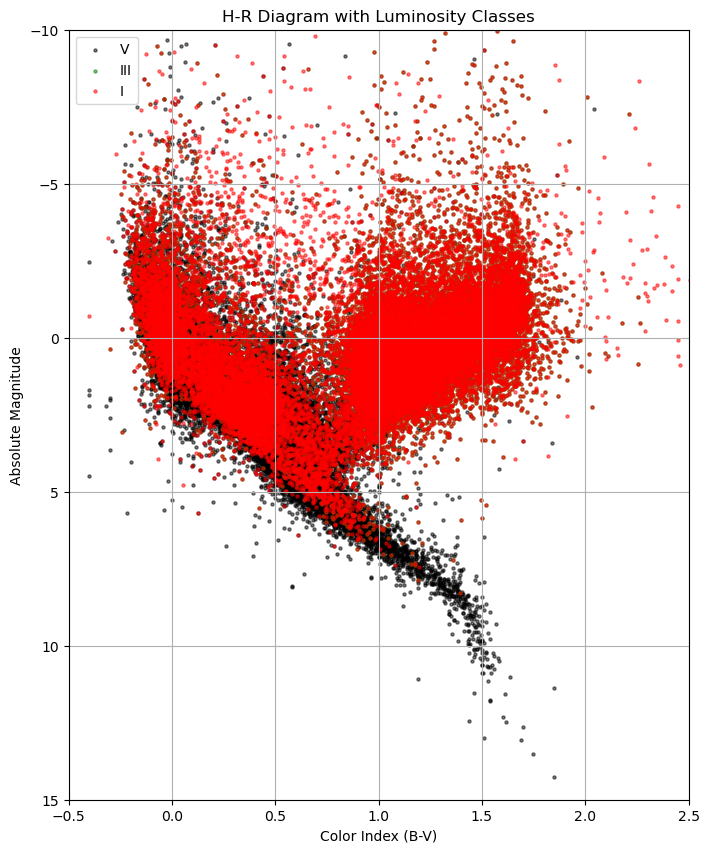

In [91]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

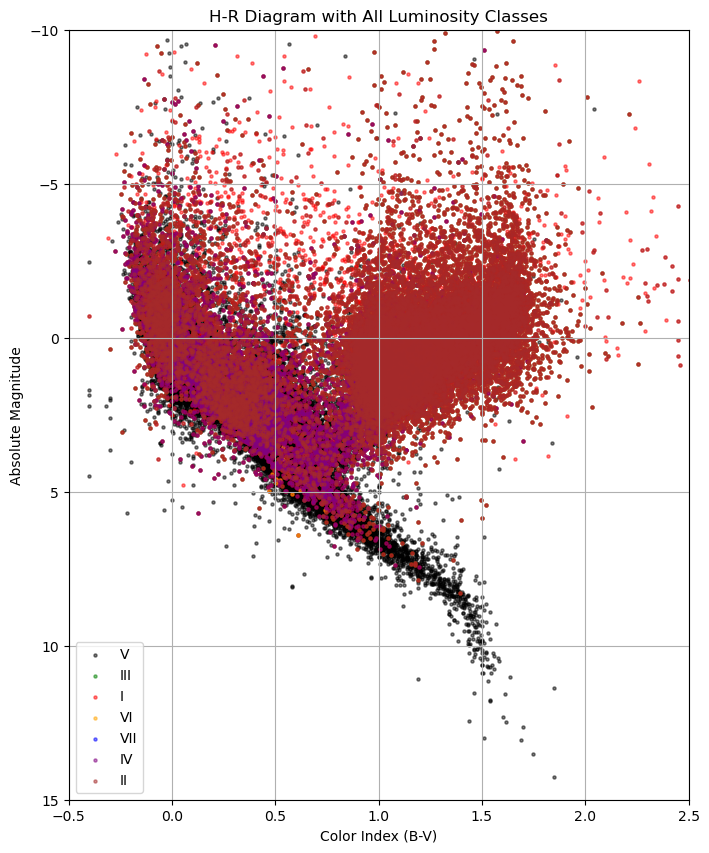

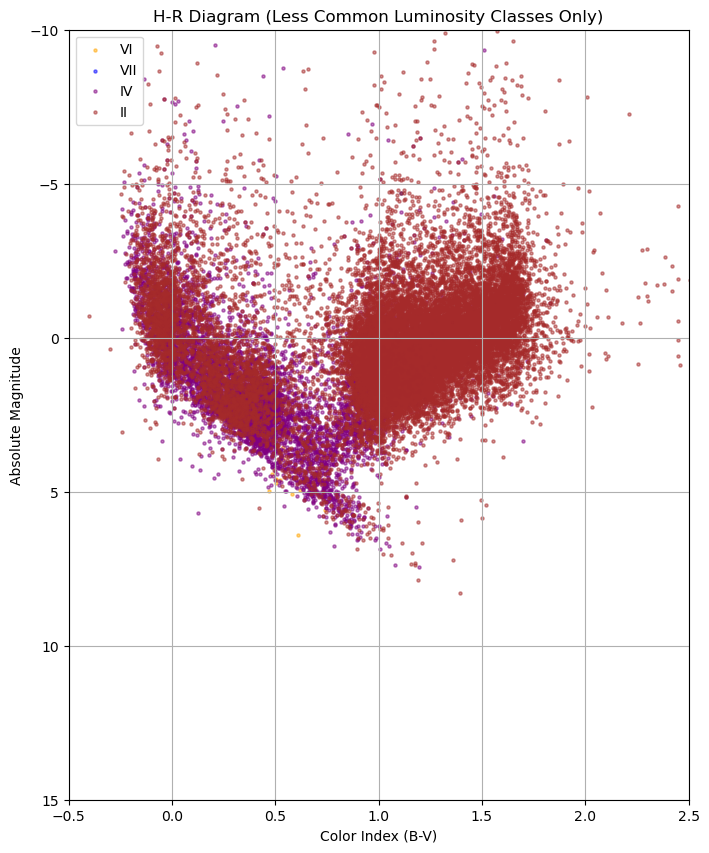

In [95]:
# First plot: Main sequence, giants, and supergiants - all classes
plt.figure(figsize=(8, 10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with All Luminosity Classes')

# Standard types
plot_luminosity_class(cluster_df_clean, 'V', 'black')    # Main Sequence
plot_luminosity_class(cluster_df_clean, 'III', 'green')  # Giants
plot_luminosity_class(cluster_df_clean, 'I', 'red')      # Supergiants

# Additional types
plot_luminosity_class(cluster_df_clean, 'VI', 'orange')  # Subdwarfs
plot_luminosity_class(cluster_df_clean, 'VII', 'blue')   # White Dwarfs
plot_luminosity_class(cluster_df_clean, 'IV', 'purple')  # Subgiants
plot_luminosity_class(cluster_df_clean, 'II', 'brown')   # Bright Giants

plt.legend()
plt.show()

# Second plot: ONLY Subdwarfs, White dwarfs, Subgiants, and Bright giants
plt.figure(figsize=(8, 10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Less Common Luminosity Classes Only)')

plot_luminosity_class(cluster_df_clean, 'VI', 'orange')  # Subdwarfs
plot_luminosity_class(cluster_df_clean, 'VII', 'blue')   # White Dwarfs
plot_luminosity_class(cluster_df_clean, 'IV', 'purple')  # Subgiants
plot_luminosity_class(cluster_df_clean, 'II', 'brown')   # Bright Giants

plt.legend()
plt.show()

# I hope I understood the instructions correctly...

Submit your FITS file and this notebook to Gradescope!